In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data = pd.read_csv(r"E:\fear_greed_index.csv")
data


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [4]:
data2 = pd.read_csv(r"E:\historical_data.csv")
data

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


## converting timestamp to datetime

In [10]:
data["timestamp"] = pd.to_datetime(data["timestamp"])
data2["timestamp"] = pd.to_datetime(data["timestamp"])
data2.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,1970-01-01 00:00:01.517463000,1970-01-01
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,1970-01-01 00:00:01.517549400,1970-01-01
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,1970-01-01 00:00:01.517635800,1970-01-01
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,1970-01-01 00:00:01.517722200,1970-01-01
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,1970-01-01 00:00:01.517808600,1970-01-01


In [9]:
# extract date only 
data["date"] = data["timestamp"].dt.date
data2["date"] = data2["timestamp"].dt.date
data.head()

,timestamp,value,classification,date
0,1970-01-01 00:00:01.517463000,30,Fear,1970-01-01
1,1970-01-01 00:00:01.517549400,15,Extreme Fear,1970-01-01
2,1970-01-01 00:00:01.517635800,40,Fear,1970-01-01
3,1970-01-01 00:00:01.517722200,24,Extreme Fear,1970-01-01
4,1970-01-01 00:00:01.517808600,11,Extreme Fear,1970-01-01


In [13]:
daily_pnl = (
    data2.groupby(["date", "Trade ID"])["Closed PnL"]
    .sum()
    .reset_index()
    .rename(columns={"pnl": "daily_pnl"})
)

print(daily_pnl.head())

         date      Trade ID  Closed PnL
0  1970-01-01  0.000000e+00      0.0000
1  1970-01-01  3.490000e+11      0.0000
2  1970-01-01  1.090000e+12      0.0000
3  1970-01-01  1.250000e+12     11.8130
4  1970-01-01  2.440000e+12     25.3038


In [17]:
win_rate = (
    data2.assign(win=data2["Closed PnL"] > 0)
      .groupby("Trade ID")["win"]
      .mean()
      .reset_index()
      .rename(columns={"win": "win_rate"})
)

print(win_rate.head())

       Trade ID  win_rate
0  0.000000e+00       0.0
1  2.367595e+09       0.0
2  3.739256e+09       0.0
3  9.506002e+09       0.0
4  1.162660e+10       0.0


In [19]:
avg_trade_size = (
    data2.groupby("Trade ID")["Size Tokens"]
      .mean()
      .reset_index()
      .rename(columns={"Size Tokens": "avg_trade_size"})
)

print(avg_trade_size.head())

       Trade ID  avg_trade_size
0  0.000000e+00     1485.695785
1  2.367595e+09      372.190000
2  3.739256e+09        0.013000
3  9.506002e+09       52.550000
4  1.162660e+10      166.500000


In [21]:
data2["leverage"] = data2["Size USD"] / data2["Start Position"]
print(data2[["Size USD", "Start Position", "leverage"]].head())



   Size USD  Start Position  leverage
0   7872.16        0.000000       inf
1    127.68      986.524596  0.129424
2   1150.63     1002.518996  1.147739
3   1142.04     1146.558564  0.996059
4     69.75     1289.488521  0.054091


In [22]:
leverage_stats = data2["leverage"].describe()
print(leverage_stats)

count    2.112240e+05
mean              inf
std               NaN
min     -1.045050e+10
25%     -2.710120e-02
50%      1.353705e-02
75%      6.390805e-01
max               inf
Name: leverage, dtype: float64


C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [23]:
trades_per_day = (
    data2.groupby("date")
      .size()
      .reset_index(name="num_trades")
)

print(trades_per_day.head())

         date  num_trades
0  1970-01-01        2644


In [25]:
long_short_ratio = (
    data2["Side"].value_counts(normalize=True)
)

print(long_short_ratio)

Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


In [26]:
daily_long_short = (
    data2.groupby(["date", "Side"])
      .size()
      .unstack(fill_value=0)
)

daily_long_short["long_short_ratio"] = (
    daily_long_short.get("long", 0) /
    daily_long_short.get("short", 1)
)

print(daily_long_short.head())

Side         BUY  SELL  long_short_ratio
date                                    
1970-01-01  1194  1450               0.0


In [29]:
data2.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,timestamp,date,leverage
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,1970-01-01 00:00:01.517463000,1970-01-01,inf
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,1970-01-01 00:00:01.517549400,1970-01-01,0.129424
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,1970-01-01 00:00:01.517635800,1970-01-01,1.147739
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,1970-01-01 00:00:01.517722200,1970-01-01,0.996059
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,1970-01-01 00:00:01.517808600,1970-01-01,0.054091


In [32]:
data_n = data2.merge(
    data[["date", "classification"]],
    on="date",
    how="left"
)

print(data_n.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50             0.0       Buy   
1       986.87   7872.16  BUY  02-12-2024 22:50             0.0       Buy   
2       986.87   7872.16  BUY  02-12-2024 22:50             0.0       Buy   
3       986.87   7872.16  BUY  02-12-2024 22:50             0.0       Buy   
4       986.87   7872.16  BUY  02-12-2024 22:50             0.0       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

  classification  Closed PnL
0   Extreme Fear  246.489341
1  Extreme Greed  246.489341
2           Fear  246.489341
3          Greed  246.489341
4        Neutral  246.489341


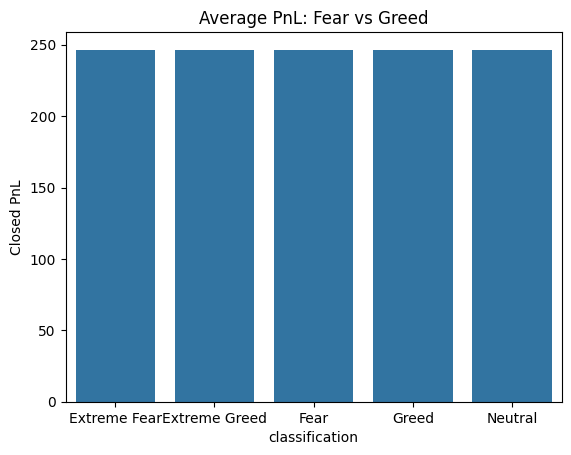

In [33]:
pnl_by_sentiment = (
    data_n.groupby("classification")["Closed PnL"]
    .mean()
    .reset_index()
)

print(pnl_by_sentiment)

sns.barplot(data=pnl_by_sentiment, x="classification", y="Closed PnL")
plt.title("Average PnL: Fear vs Greed")
plt.show()

  classification       win
0   Extreme Fear  0.414523
1  Extreme Greed  0.414523
2           Fear  0.414523
3          Greed  0.414523
4        Neutral  0.414523


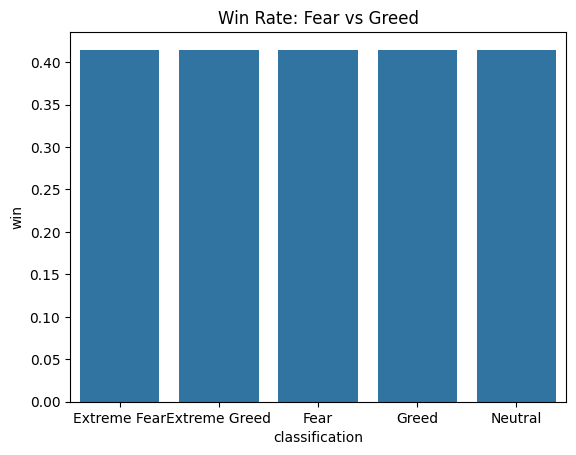

In [38]:
win_rate = (
    data_n.groupby("classification")["win"]
    .mean()
    .reset_index()
)

print(win_rate)

sns.barplot(data=win_rate, x="classification", y="win")
plt.title("Win Rate: Fear vs Greed")
plt.show()

In [36]:
data_n = data_n.sort_values("Timestamp IST")
data_n["cum_pnl"] = data_n["Closed PnL"].cumsum()
data_n["running_max"] = data_n["cum_pnl"].cummax()
data_n["drawdown"] = data_n["cum_pnl"] - data_n["running_max"]

drawdown_by_sentiment = (
    data_n.groupby("classification")["drawdown"]
    .mean()
    .reset_index()
)

print(drawdown_by_sentiment)

  classification      drawdown
0   Extreme Fear -1.564350e+06
1  Extreme Greed -1.567101e+06
2           Fear -1.564619e+06
3          Greed -1.565802e+06
4        Neutral -1.564485e+06


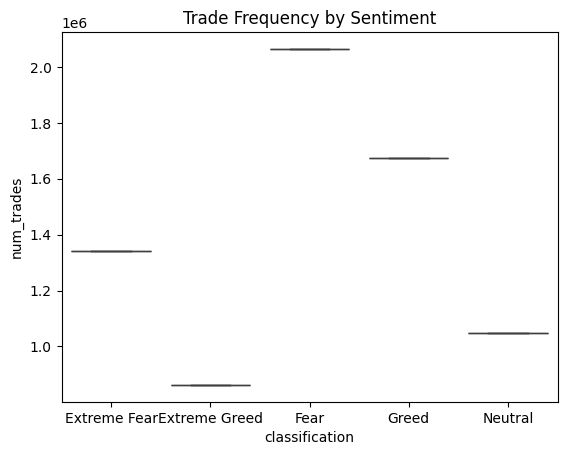

In [39]:
trades_per_day = (
    data_n.groupby(["date", "classification"])
    .size()
    .reset_index(name="num_trades")
)

sns.boxplot(data=trades_per_day, x="classification", y="num_trades")
plt.title("Trade Frequency by Sentiment")
plt.show()

  classification     Size USD
0   Extreme Fear  2387.767723
1  Extreme Greed  2387.767723
2           Fear  2387.767723
3          Greed  2387.767723
4        Neutral  2387.767723


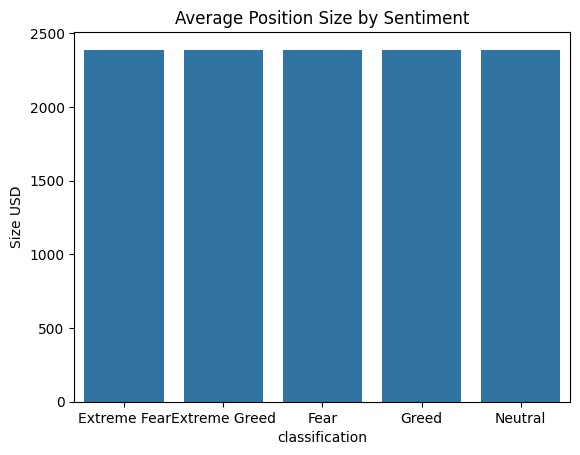

In [43]:
size_behavior = (
    data_n.groupby("classification")["Size USD"]
    .mean()
    .reset_index()
)

print(size_behavior)

sns.barplot(data=size_behavior, x="classification", y="Size USD")
plt.title("Average Position Size by Sentiment")
plt.show()

In [44]:
long_short = (
    data_n.groupby(["classification", "Side"])
    .size()
    .unstack(fill_value=0)
)

long_short["long_short_ratio"] = (
    long_short.get("BUY", 0) /
    long_short.get("SELL", 1)
)

print(long_short)

Side               BUY     SELL  long_short_ratio
classification                                   
Extreme Fear    606552   736600          0.823448
Extreme Greed   389244   472700          0.823448
Fear            932514  1132450          0.823448
Greed           755802   917850          0.823448
Neutral         472824   574200          0.823448


In [45]:
threshold = data_n["Size USD"].median()

data_n["size_segment"] = np.where(
    data_n["Size USD"] > threshold,
    "High Size",
    "Low Size"
)

segment_perf = (
    data_n.groupby("size_segment")["Closed PnL"]
    .mean()
    .reset_index()
)

print(segment_perf)

  size_segment  Closed PnL
0    High Size  466.872814
1     Low Size   14.826552


In [48]:
consistency = (
    data_n.groupby("Trade ID")["Closed PnL"]
    .std()
    .reset_index(name="pnl_std")
)

std_threshold = consistency["pnl_std"].median()

consistency["consistency_segment"] = np.where(
    consistency["pnl_std"] < std_threshold,
    "Consistent",
    "Inconsistent"
)

data_n = data_n.merge(consistency[["Trade ID", "consistency_segment"]],
                  on="Trade ID")

consistency_perf = (
    data_n.groupby("consistency_segment")["Closed PnL"]
    .mean()
    .reset_index()
)

print(consistency_perf)

  consistency_segment  Closed PnL
0          Consistent   15.917177
1        Inconsistent  338.722308


In [55]:
from scipy.stats import ttest_ind

fear_pnl = data_n[data_n["classification"] == "Fear"]["Closed PnL"]
greed_pnl = data_n[data_n["classification"] == "Greed"]["Closed PnL"]

t_stat, p_value = ttest_ind(fear_pnl, greed_pnl, equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: 8.81204062955317e-14
P-value: 0.9999999999999296


In [56]:
data_n.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,timestamp,date,leverage,classification,win,cum_pnl,running_max,drawdown,size_segment,consistency_segment
0,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2299.5,0.25000,574.88,BUY,01-01-2024 01:23,0.0000,Open Long,0.0,...,NaT,NaT,inf,NaN,False,0.0,0.0,0.0,Low Size,Inconsistent
1,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2299.7,0.01270,29.21,BUY,01-01-2024 01:23,0.6850,Open Long,0.0,...,NaT,NaT,4.264234e+01,NaN,False,0.0,0.0,0.0,Low Size,Inconsistent
2,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2299.8,1.12500,2587.28,BUY,01-01-2024 01:23,0.6977,Open Long,0.0,...,NaT,NaT,3.708299e+03,NaN,False,0.0,0.0,0.0,High Size,Inconsistent
3,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2299.9,20.28760,46659.45,BUY,01-01-2024 01:23,1.8227,Open Long,0.0,...,NaT,NaT,2.559908e+04,NaN,False,0.0,0.0,0.0,High Size,Consistent
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,42693.0,0.02305,984.07,SELL,01-01-2024 01:23,0.0000,Open Short,0.0,...,NaT,NaT,inf,NaN,False,0.0,0.0,0.0,High Size,Consistent


In [61]:
def adjust_leverage(row):
    if row['classification'] == 'Fear' and row['size_segment'] == 'High Size':
        # During Fear days, reduce leverage for high size traders
        return max(row['leverage'] * 0.7, 1)  # reduce by 30%, minimum 1x leverage
    elif row['classification'] == 'Greed' and row['consistency_segment'] == 'Frequent':
        # During Greed days, increase leverage for frequent traders
        return row['leverage'] * 1.2  # increase by 20%
    else:
        # Otherwise keep leverage unchanged
        return row['leverage']

# Apply to your data
data_n['adjusted_leverage'] = data_n.apply(adjust_leverage, axis=1)

In [62]:
data_n.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,date,leverage,classification,win,cum_pnl,running_max,drawdown,size_segment,consistency_segment,adjusted_leverage
0,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2299.5,0.25000,574.88,BUY,01-01-2024 01:23,0.0000,Open Long,0.0,...,NaT,inf,NaN,False,0.0,0.0,0.0,Low Size,Inconsistent,inf
1,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2299.7,0.01270,29.21,BUY,01-01-2024 01:23,0.6850,Open Long,0.0,...,NaT,4.264234e+01,NaN,False,0.0,0.0,0.0,Low Size,Inconsistent,4.264234e+01
2,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2299.8,1.12500,2587.28,BUY,01-01-2024 01:23,0.6977,Open Long,0.0,...,NaT,3.708299e+03,NaN,False,0.0,0.0,0.0,High Size,Inconsistent,3.708299e+03
3,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2299.9,20.28760,46659.45,BUY,01-01-2024 01:23,1.8227,Open Long,0.0,...,NaT,2.559908e+04,NaN,False,0.0,0.0,0.0,High Size,Consistent,2.559908e+04
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,42693.0,0.02305,984.07,SELL,01-01-2024 01:23,0.0000,Open Short,0.0,...,NaT,inf,NaN,False,0.0,0.0,0.0,High Size,Consistent,inf
